In [ ]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import random


In [15]:
data_dir = "mini_speech_commands"  # map met submappen: up/, down/, left/, right/

commands = os.listdir(data_dir)
print("Commands:", commands)


Commands: ['down', 'go', 'left', 'no', 'right', 'stop', 'up', 'yes']


In [16]:
def extract_features(file_path, max_len=2.0):
    audio, sr = librosa.load(file_path, sr=22050)
    max_samples = int(max_len * sr)
    if len(audio) > max_samples:
        audio = audio[:max_samples]
    else:
        audio = np.pad(audio, (0, max_samples - len(audio)))

    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # ✅ Normaliseer tussen 0 en 1
    mel_spec_norm = (mel_spec_db + 80) / 80.0
    return mel_spec_norm



In [17]:
X = []
y = []

for label_idx, command in enumerate(commands):
    folder = os.path.join(data_dir, command)
    for file in os.listdir(folder):
        if file.endswith(".wav"):
            path = os.path.join(folder, file)
            features = extract_features(path)
            X.append(features)
            y.append(label_idx)

X = np.array(X)
y = np.array(y)

print("Data shape:", X.shape)


Data shape: (8000, 64, 87)


In [18]:
# Voeg kanaaldimensie toe
X = X[..., np.newaxis]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot encoding labels
num_classes = len(commands)
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)


In [19]:
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=X_train.shape[1:]),
    MaxPooling2D((2,2)),
    Dropout(0.2),
    
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.2),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
plot_model(model, show_shapes=True, show_layer_names=True)



You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [20]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=16,
)


Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2852 - loss: 1.8152 - val_accuracy: 0.4863 - val_loss: 1.3754
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4963 - loss: 1.3012 - val_accuracy: 0.6425 - val_loss: 0.9960
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5686 - loss: 1.0961 - val_accuracy: 0.7088 - val_loss: 0.8865
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6350 - loss: 0.9553 - val_accuracy: 0.7331 - val_loss: 0.7980
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6611 - loss: 0.8741 - val_accuracy: 0.7469 - val_loss: 0.7351
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6848 - loss: 0.8029 - val_accuracy: 0.7631 - val_loss: 0.6689
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7081 - loss: 0.7563 - val_accuracy: 0.8069 - val_loss: 0.5846
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7278 - loss: 0.7096 - val_accuracy: 0.

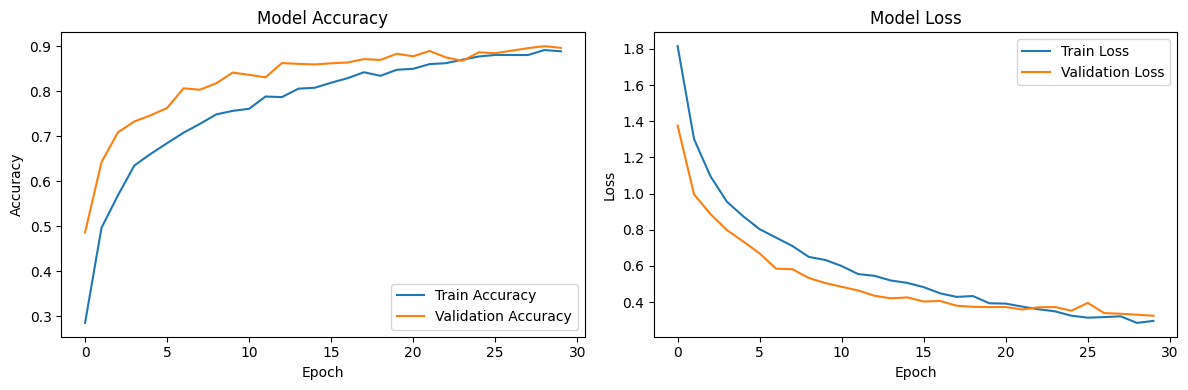

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy-plot
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Loss-plot
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Validation Loss')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()


Testbestand: mini_speech_commands\up\0132a06d_nohash_2.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


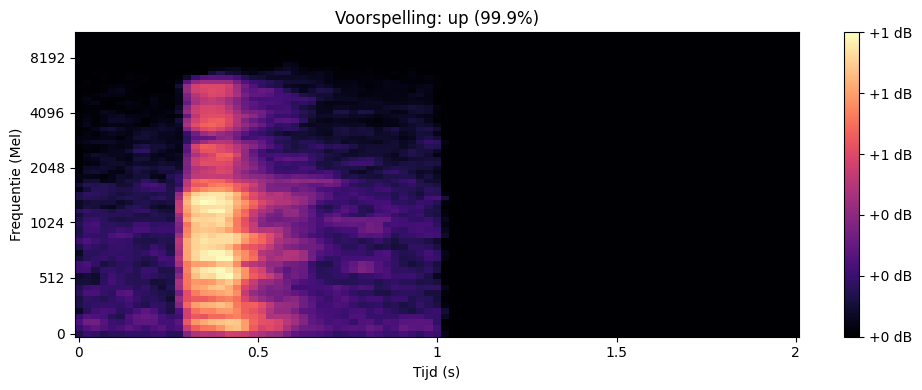

In [ ]:
# Kies willekeurig 1 voorbeeldbestand uit elke command-submap
sample_paths = []
for command in commands:
    folder = os.path.join(data_dir, command)
    wavs = [f for f in os.listdir(folder) if f.lower().endswith('.wav')]
    if not wavs:
        print(f"Geen .wav bestanden in: {folder} — overslaan")
        continue
    sample_paths.append(os.path.join(folder, random.choice(wavs)))

# Voorspel en toon spectrogram voor elk gekozen bestand
for sample_path in sample_paths:
    print("Testbestand:", sample_path)
    features = extract_features(sample_path)
    input_data = features[np.newaxis, ..., np.newaxis]

    prediction = model.predict(input_data)
    predicted_label = commands[np.argmax(prediction)]
    confidence = np.max(prediction)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(features, sr=22050, x_axis='time', y_axis='mel', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Voorspelling: {predicted_label} ({confidence*100:.1f}%) — {os.path.basename(sample_path)}")
    plt.xlabel("Tijd (s)")
    plt.ylabel("Frequentie (Mel)")
    plt.tight_layout()
    plt.show()